In [1]:
import dotenv
dotenv.load_dotenv('secrects.env')

True

In [3]:
import os
import re
import json
import base64
import fitz  # PyMuPDF
# import chromadb
import requests
import numpy as np
from io import BytesIO
from PIL import Image
from dataclasses import dataclass, field
from typing import Optional
# from openai import OpenAI
from paddleocr import PaddleOCR
import os, sys, json, base64, time, re
from pathlib import Path
# from dotenv import load_dotenv

import os, sys, json, base64, time, re
from pathlib import Path

# # ── API Keys ──────────────────────────────────────────────────────────────────
# os.environ["embedding_nvidia_key"] = os.getenv("embedding_nvdia_key")
# os.environ["NVIDIA_MULTIMODAL_KEY"] = os.getenv("llm_nvdia_key")

EMBED_MODEL   = "nvidia/llama-3.2-nemoretriever-300m-embed-v1"
VISION_MODEL  = "meta/llama-4-maverick-17b-128e-instruct"
NVIDIA_URL    = "https://integrate.api.nvidia.com/v1/chat/completions"

print("Environment configured")

Environment configured


In [4]:
GROQ_API_KEY    = os.getenv("groq_key", "")
NVIDIA_API_KEY  = os.getenv("embedding_nvdia_key", "")

# assert GROQ_API_KEY,   "GROQ_API_KEY missing from .env"
# assert NVIDIA_API_KEY, "NVIDIA_API_KEY missing from .env"

print("✅ Environment loaded")
print(f"   GROQ_API_KEY  : {'*' * 8}{GROQ_API_KEY[-4:]}")
print(f"   NVIDIA_API_KEY: {'*' * 8}{NVIDIA_API_KEY[-4:]}")

✅ Environment loaded
   GROQ_API_KEY  : ********
   NVIDIA_API_KEY: ********


In [18]:
# Cell 2 — Install / verify dependencies
import importlib, subprocess

REQUIRED = [
    ("fitz",        "PyMuPDF"),
    ("paddleocr",   "paddleocr"),
    ("chromadb",    "chromadb"),
    ("PIL",         "Pillow"),
    ("groq",        "groq"),
    ("yaml",        "PyYAML"),
    ("simpleeval",  "simpleeval"),
]

In [19]:
missing = []
for module, pkg in REQUIRED:
    try:
        importlib.import_module(module)
        print(f"  ✅ {pkg}")
    except ImportError:
        print(f"  ❌ {pkg} — installing …")
        subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"])
        missing.append(pkg)

if missing:
    print(f"\n⚠  Re-run after install: {missing}")
else:
    print("\n✅ All dependencies available")

  ✅ PyMuPDF
  ✅ paddleocr
  ✅ chromadb
  ✅ Pillow
  ✅ groq
  ✅ PyYAML
  ✅ simpleeval

✅ All dependencies available


In [5]:
DEMO_CONFIG = {
    "pdf_path": r"sample_sbc.pdf",  # override below
    "top_k_retrieval": 2,
    "top_k_fallback":  4,
    "confidence_threshold": 0.75,
    "render_dpi": 150,
    "embed_model": "nvidia/llama-3.2-nemoretriever-300m-embed-v1",
    "llm_model":   "meta/llama-4-maverick-17b-128e-instruct",
    "nvidia_embed_url": "https://integrate.api.nvidia.com/v1",
    "groq_base_url":    None,   # uses groq SDK default
}

In [6]:
# ── quick demo: use a generated synthetic PDF if real one is absent ──────────
demo_pdf_path = Path(DEMO_CONFIG["pdf_path"])
USE_SYNTHETIC = not demo_pdf_path.exists()
print(f"PDF exists : {demo_pdf_path.exists()} → {'using synthetic' if USE_SYNTHETIC else 'using real file'}")

PDF exists : False → using synthetic


In [7]:
# Synthetic PDF generator (used when real PDF is absent)
def create_synthetic_sbc_pdf(output_path: str) -> str:
    """Create a minimal 4-page SBC-style PDF for pipeline demonstration."""
    import fitz

    SBC_PAGES = [
        {
            "title": "Summary of Benefits and Coverage",
            "body": (
                "Plan Name: HealthFirst Gold PPO\n"
                "Coverage Period: 01/01/2024 – 12/31/2024\n\n"
                "DEDUCTIBLES\n"
                "Individual Deductible (In-Network): $1,500\n"
                "Family Deductible (In-Network): $3,000\n"
                "Individual Deductible (Out-of-Network): $4,500\n"
            ),
        },
        {
            "title": "Out-of-Pocket Maximums",
            "body": (
                "Individual Out-of-Pocket Maximum (In-Network): $5,000\n"
                "Family Out-of-Pocket Maximum (In-Network): $10,000\n"
                "Individual Out-of-Pocket Maximum (Out-of-Network): $15,000\n\n"
                "These limits include deductibles, copayments, and coinsurance.\n"
            ),
        },
        {
            "title": "Copayments and Coinsurance",
            "body": (
                "Primary Care Visit: $25 copay after deductible\n"
                "Specialist Visit: $50 copay after deductible\n"
                "Emergency Room: $250 copay then 20% coinsurance\n"
                "Urgent Care: $40 copay\n"
                "Preventive Care: No charge (covered in full)\n"
            ),
        },
        {
            "title": "Prescription Drug Benefits",
            "body": (
                "Tier 1 Generic: $10 copay per 30-day supply\n"
                "Tier 2 Preferred Brand: $40 copay per 30-day supply\n"
                "Tier 3 Non-Preferred Brand: $80 copay per 30-day supply\n"
                "Tier 4 Specialty: 25% coinsurance up to $250 per fill\n"
                "Mail Order (90-day supply): 2.5x retail copay\n"
            ),
        },
    ]

    doc = fitz.open()
    for page_data in SBC_PAGES:
        page = doc.new_page(width=612, height=792)
        # header
        page.insert_text((72, 60),  page_data["title"], fontsize=14, color=(0, 0, 0.6))
        page.draw_line((72, 75), (540, 75), color=(0.3, 0.3, 0.3), width=1)
        # body
        y = 100
        for line in page_data["body"].split("\n"):
            fs = 9 if line.startswith(" ") else 10
            page.insert_text((72, y), line, fontsize=fs)
            y += 18

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    doc.save(output_path)
    doc.close()
    print(f"✅ Synthetic SBC PDF saved → {output_path}")
    return output_path


In [33]:
if USE_SYNTHETIC:
    synthetic_path = "/tmp/demo_sbc.pdf"
    DEMO_CONFIG["pdf_path"] = create_synthetic_sbc_pdf(synthetic_path)
    demo_pdf_path = Path(DEMO_CONFIG["pdf_path"])

✅ Synthetic SBC PDF saved → /tmp/demo_sbc.pdf


In [ ]:
# #  — Layer 1 · Document Loading (PyMuPDF)
# import fitz
# from PIL import Image
# import io

# class PageImageStore:
#     """Holds base64-encoded RGB images keyed by 0-based page index."""

#     def __init__(self):
#         self._store: dict[int, str] = {}
#         self.page_count = 0

#     def add(self, page_num: int, image_b64: str):
#         self._store[page_num] = image_b64
#         self.page_count = len(self._store)

#     def get(self, page_num: int) -> str | None:
#         return self._store.get(page_num)

#     def all_pages(self) -> list[int]:
#         return sorted(self._store.keys())


# def load_pdf_pages(pdf_path: str, dpi: int = 150) -> PageImageStore:
#     store = PageImageStore()
#     doc = fitz.open(pdf_path)
#     mat = fitz.Matrix(dpi / 72, dpi / 72)

#     for page_num in range(len(doc)):
#         page = doc[page_num]
#         pix  = page.get_pixmap(matrix=mat, colorspace=fitz.csRGB)
#         img  = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
#         buf  = io.BytesIO()
#         img.save(buf, format="PNG")
#         b64  = base64.b64encode(buf.getvalue()).decode("utf-8")
#         store.add(page_num, b64)
#         print(f"  Page {page_num}: {pix.width}×{pix.height}px — {len(b64)//1024} KB (b64)")

#     doc.close()
#     return store


# print("=" * 60)
# print("LAYER 1 — Document Loading")
# print("=" * 60)
# page_store = load_pdf_pages(DEMO_CONFIG["pdf_path"], dpi=DEMO_CONFIG["render_dpi"])
# print(f"\n✅ Loaded {page_store.page_count} pages from PDF")

LAYER 1 — Document Loading
  Page 0: 1275×1650px — 70 KB (b64)
  Page 1: 1275×1650px — 64 KB (b64)
  Page 2: 1275×1650px — 67 KB (b64)
  Page 3: 1275×1650px — 72 KB (b64)

✅ Loaded 4 pages from PDF


In [34]:
from src.ingestion.page_image_store import PageImageStore
page_store = PageImageStore(dpi=DEMO_CONFIG["render_dpi"])
page_store.load_pdf(DEMO_CONFIG["pdf_path"])

4

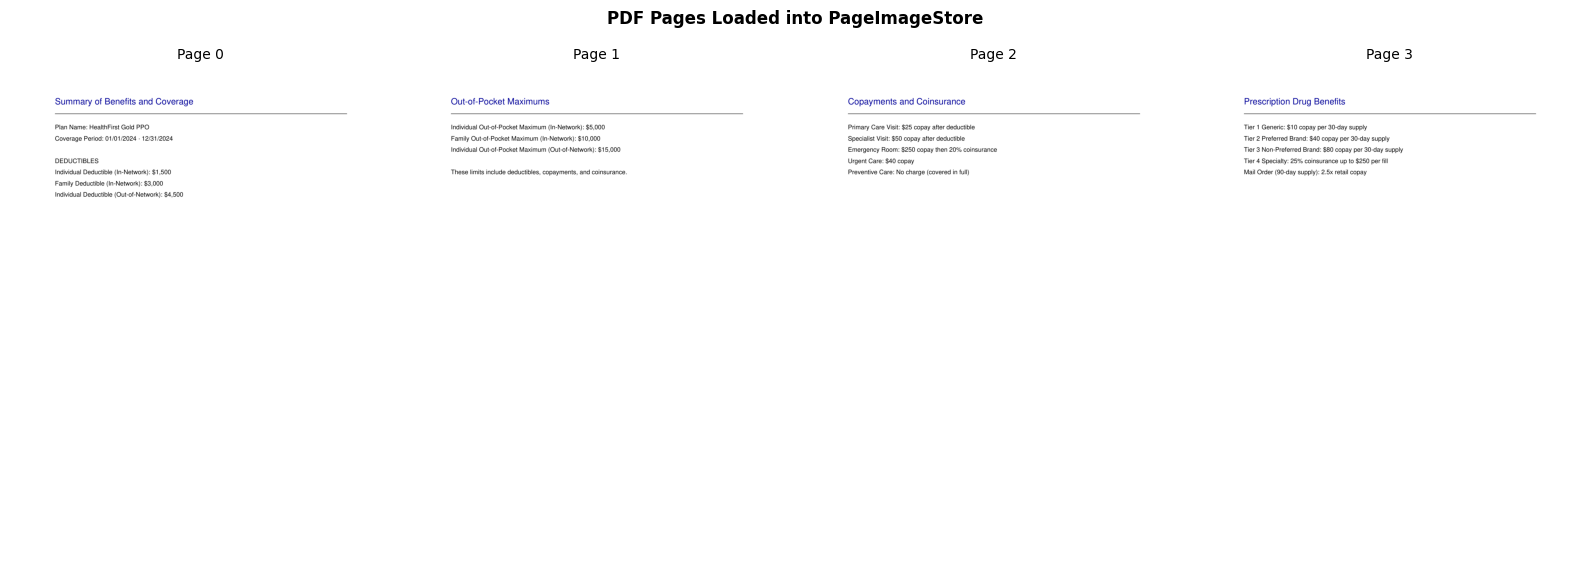

✅ Rendered 4 page previews


In [39]:
# Layer 1 · Visual inspection of first page
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, min(page_store.page_count(), 4), figsize=(16, 6))
if page_store.page_count() == 1:
    axes = [axes]

for idx, pg in enumerate(page_store.all_pages()[:4]):
    b64 = page_store.get(pg)
    img_bytes = base64.b64decode(b64)
    img = Image.open(io.BytesIO(img_bytes))
    axes[idx].imshow(img)
    axes[idx].set_title(f"Page {pg}", fontsize=10)
    axes[idx].axis("off")

plt.suptitle("PDF Pages Loaded into PageImageStore", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"✅ Rendered {min(page_store.page_count(), 4)} page previews")

In [ ]:
# Cell 7 — Layer 2 · OCR Processing (PaddleOCR Mobile)
from paddleocr import PaddleOCR
from dataclasses import dataclass, field

@dataclass
class StructuredPage:
    page_num:       int
    raw_text:       str = ""
    section_headers: list[str] = field(default_factory=list)
    key_value_pairs: list[tuple[str, str]] = field(default_factory=list)
    composite_index: str = ""   # fed into the embedding model


def _is_header_candidate(text: str) -> bool:
    """Heuristic: short, title-case or uppercase line = section header."""
    stripped = text.strip()
    return (
        len(stripped) < 60
        and len(stripped.split()) <= 8
        and (stripped.isupper() or stripped.istitle())
    )


def _extract_kv(text: str) -> tuple[str, str] | None:
    """Detect 'Label: Value' or 'Label — Value' patterns."""
    for sep in (":", "—", "-"):
        if sep in text:
            parts = text.split(sep, 1)
            if 2 <= len(parts[0].strip()) <= 60:
                return parts[0].strip(), parts[1].strip()
    return None


def ocr_page(ocr_engine: PaddleOCR, page_num: int, b64_image: str) -> StructuredPage:
    img_bytes = base64.b64decode(b64_image)
    img_array = __import__("numpy").frombuffer(img_bytes, dtype=__import__("numpy").uint8)
    img_bgr   = __import__("cv2").imdecode(img_array, __import__("cv2").IMREAD_COLOR)

    result = ocr_engine.ocr(img_bgr, cls=True)
    sp = StructuredPage(page_num=page_num)

    lines = []
    if result and result[0]:
        for line_info in result[0]:
            text = line_info[1][0].strip()
            if not text:
                continue
            lines.append(text)
            if _is_header_candidate(text):
                sp.section_headers.append(text)
            kv = _extract_kv(text)
            if kv:
                sp.key_value_pairs.append(kv)

    sp.raw_text = "\n".join(lines)

    # Build composite index text — headers first for signal priority
    headers_str   = " | ".join(sp.section_headers) if sp.section_headers else ""
    kv_str        = " | ".join(f"{k}: {v}" for k, v in sp.key_value_pairs)
    sp.composite_index = (
        f"SECTIONS: {headers_str} | "
        f"KEY_VALUES: {kv_str} | "
        f"{sp.raw_text}"
    )
    return sp


print("=" * 60)
print("LAYER 2 — OCR Processing (PaddleOCR Mobile)")
print("=" * 60)

import traceback
try:
    import cv2  # noqa
    ocr_engine = PaddleOCR(use_textline_orientation=True, lang="en", show_log=False)
    structured_pages: dict[int, StructuredPage] = {}

    for pg in page_store.all_pages():
        sp = ocr_page(ocr_engine, pg, page_store.get(pg))
        structured_pages[pg] = sp
        print(f"\n  Page {pg}:")
        print(f"    Headers   : {sp.section_headers}")
        print(f"    KV pairs  : {len(sp.key_value_pairs)}")
        print(f"    Index text: {sp.composite_index[:120]}…")

    USE_OCR = True
    print("\n✅ OCR complete")

except Exception as e:

    traceback.print_exc()
    print(f"⚠  PaddleOCR unavailable ({e}) — using PyMuPDF text fallback for demo")
    USE_OCR = False

    doc = fitz.open(DEMO_CONFIG["pdf_path"])
    structured_pages = {}
    for pg in range(len(doc)):
        raw = doc[pg].get_text("text")
        sp  = StructuredPage(page_num=pg, raw_text=raw)
        lines = [l.strip() for l in raw.split("\n") if l.strip()]
        sp.section_headers = [l for l in lines if _is_header_candidate(l)]
        for l in lines:
            kv = _extract_kv(l)
            if kv:
                sp.key_value_pairs.append(kv)
        headers_str = " | ".join(sp.section_headers)
        kv_str      = " | ".join(f"{k}: {v}" for k, v in sp.key_value_pairs)
        sp.composite_index = f"SECTIONS: {headers_str} | KEY_VALUES: {kv_str} | {raw}"
        structured_pages[pg] = sp
        print(f"  Page {pg}: {len(sp.section_headers)} headers, {len(sp.key_value_pairs)} KV pairs")
    doc.close()
    print("✅ Fallback OCR complete")

LAYER 2 — OCR Processing (PaddleOCR Mobile)
⚠  PaddleOCR unavailable (Unknown argument: show_log) — using PyMuPDF text fallback for demo
  Page 0: 4 headers, 5 KV pairs
  Page 1: 0 headers, 4 KV pairs
  Page 2: 0 headers, 5 KV pairs
  Page 3: 1 headers, 5 KV pairs
✅ Fallback OCR complete


Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Temp\ipykernel_6160\996081744.py", line 75, in <module>
    ocr_engine = PaddleOCR(use_textline_orientation=True, lang="en", show_log=False)
  File "C:\Users\User\anaconda3\Lib\site-packages\paddleocr\_pipelines\ocr.py", line 163, in __init__
    super().__init__(**base_params)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\paddleocr\_pipelines\base.py", line 63, in __init__
    self._common_args = parse_common_args(
                        ~~~~~~~~~~~~~~~~~^
        common_args, default_enable_hpi=_DEFAULT_ENABLE_HPI
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\User\anaconda3\Lib\site-packages\paddleocr\_common_args.py", line 45, in parse_common_args
    raise ValueError(f"Unknown argument: {name}")
ValueError: Unknown argument: show_log


In [43]:
from src.ocr.ocr_engine import OCREngine
ocr_engine = OCREngine(engine="paddle", use_doc_orientation_classify=True, use_doc_unwarping=True)
st_page = ocr_engine.process_pdf(DEMO_CONFIG["pdf_path"])

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/mayank/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
/Users/mayank/Desktop/dsai/ml3-v2/ml3/.venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/mayank/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/mayank/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_ser

: 

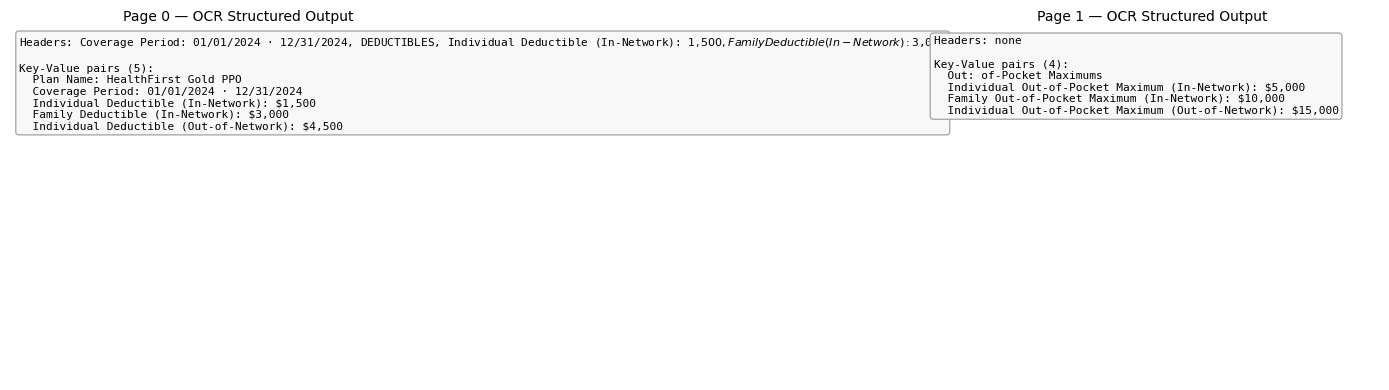

In [30]:
# OCR quality visualisation
fig, axes = plt.subplots(1, min(len(structured_pages), 2), figsize=(14, 4))
if len(structured_pages) == 1:
    axes = [axes]

for idx, (pg, sp) in enumerate(list(structured_pages.items())[:2]):
    text_block = (
        f"Headers: {', '.join(sp.section_headers) or 'none'}\n\n"
        f"Key-Value pairs ({len(sp.key_value_pairs)}):\n"
        + "\n".join(f"  {k}: {v}" for k, v in sp.key_value_pairs[:8])
        + (f"\n  … +{len(sp.key_value_pairs)-8} more" if len(sp.key_value_pairs) > 8 else "")
    )
    axes[idx].text(0.02, 0.98, text_block,
                   transform=axes[idx].transAxes,
                   va="top", ha="left", fontsize=8,
                   fontfamily="monospace",
                   bbox=dict(boxstyle="round", fc="#f8f8f8", ec="#aaa"))
    axes[idx].set_title(f"Page {pg} — OCR Structured Output", fontsize=10)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [31]:
#Layer 3 · Dense Vector Index Construction
import chromadb
from openai import OpenAI as NvidiaClient   # NVIDIA NIM is OpenAI-compatible

def embed_texts(
    texts: list[str],
    api_key: str,
    model: str,
    base_url: str,
    input_type: str = "passage",   # "passage" for indexing, "query" for retrieval
    truncate: str = "END",         # "NONE" | "START" | "END"
) -> list[list[float]]:
    """
    Call NVIDIA NIM embedding endpoint using the proper NVIDIA API parameters.
    
    Args:
        texts      : List of strings to embed
        api_key    : NVIDIA API key
        model      : Embedding model name (e.g. nvidia/llama-3.2-nemoretriever-300m-embed-v1)
        base_url   : NVIDIA NIM base URL (e.g. https://integrate.api.nvidia.com/v1)
        input_type : "passage" when indexing documents, "query" when embedding search queries
        truncate   : How to handle long inputs — "END" trims tail, "START" trims head, "NONE" errors
    
    Returns:
        List of float embedding vectors
    """
    client = NvidiaClient(api_key=api_key, base_url=base_url)

    resp = client.embeddings.create(
        model=model,
        input=texts,
        encoding_format="float",
        extra_body={
            "input_type": input_type,   # ← NVIDIA-specific: distinguishes doc vs query embeddings
            "truncate": truncate,       # ← NVIDIA-specific: handles token limit gracefully
        }
    )
    return [item.embedding for item in resp.data]


def build_chroma_index(
    structured_pages: dict[int, StructuredPage],
    api_key: str,
    embed_model: str,
    embed_url: str,
    collection_name: str = "doc_pages",
) -> chromadb.Collection:
    """Embed every page's composite index text and store in ChromaDB."""
    client = chromadb.Client()   # ephemeral / in-memory

    # Drop if exists (re-run safety)
    try:
        client.delete_collection(collection_name)
    except Exception:
        pass

    collection = client.create_collection(
        collection_name,
        metadata={"hnsw:space": "cosine"},
    )

    page_nums = sorted(structured_pages.keys())
    texts     = [structured_pages[p].composite_index for p in page_nums]

    print(f"  Embedding {len(texts)} pages via NVIDIA NIM …")
    t0 = time.time()

    # ✅ Use input_type="passage" for document indexing
    vectors = embed_texts(
        texts,
        api_key=api_key,
        model=embed_model,
        base_url=embed_url,
        input_type="passage",   # documents go in as "passage"
        truncate="END",         # silently trim overlong pages at the end
    )

    elapsed = time.time() - t0
    print(f"  Embedding done in {elapsed:.2f}s")

    collection.add(
        ids=[str(p) for p in page_nums],
        embeddings=vectors,
        documents=texts,
        metadatas=[{"page_num": p} for p in page_nums],
    )
    print(f"  ✅ Indexed {len(page_nums)} vectors in ChromaDB (in-memory)")
    return collection


print("=" * 60)
print("LAYER 3 — Dense Vector Index Construction")
print("=" * 60)

chroma_collection = build_chroma_index(
    structured_pages,
    api_key     = NVIDIA_API_KEY,
    embed_model = DEMO_CONFIG["embed_model"],
    embed_url   = DEMO_CONFIG["nvidia_embed_url"],
)

LAYER 3 — Dense Vector Index Construction
  Embedding 4 pages via NVIDIA NIM …
  Embedding done in 1.09s
  ✅ Indexed 4 vectors in ChromaDB (in-memory)


In [32]:
# Demo config sections (mirrors healthcare_sbc_config.yaml structure)
DEMO_SECTIONS = [
    {
        "section_name": "Deductibles",
        "section_description": "Annual amounts a member must pay before insurance coverage begins",
        "section_keywords": ["deductible", "before your plan pays", "annual", "individual", "family"],
        "entities": [
            {"entity_name": "individual_deductible_in_network",  "entity_description": "Per-person annual deductible for in-network providers", "entity_example_value": "$1,500"},
            {"entity_name": "family_deductible_in_network",      "entity_description": "Annual deductible for the entire family for in-network providers", "entity_example_value": "$3,000"},
            {"entity_name": "individual_deductible_out_of_network", "entity_description": "Per-person annual deductible for out-of-network providers", "entity_example_value": "$4,500"},
        ],
    },
    {
        "section_name": "Out-of-Pocket Maximums",
        "section_description": "Annual cap on total member cost-sharing obligations",
        "section_keywords": ["out-of-pocket", "maximum", "limit", "stop-loss", "oop"],
        "entities": [
            {"entity_name": "individual_oop_max_in_network", "entity_description": "Per-person annual out-of-pocket maximum for in-network care", "entity_example_value": "$5,000"},
            {"entity_name": "family_oop_max_in_network",     "entity_description": "Family annual out-of-pocket maximum for in-network care",  "entity_example_value": "$10,000"},
        ],
    },
    {
        "section_name": "Copayments and Coinsurance",
        "section_description": "Fixed dollar or percentage member cost-sharing per service visit",
        "section_keywords": ["copay", "coinsurance", "specialist", "emergency", "primary care", "preventive"],
        "entities": [
            {"entity_name": "primary_care_copay",  "entity_description": "Member copay for a primary care physician visit", "entity_example_value": "$25"},
            {"entity_name": "specialist_copay",    "entity_description": "Member copay for a specialist visit",            "entity_example_value": "$50"},
            {"entity_name": "emergency_room_copay","entity_description": "Member copay for an emergency room visit",       "entity_example_value": "$250"},
        ],
    },
    {
        "section_name": "Prescription Drug Costs",
        "section_description": "Member cost-sharing for prescription medications by tier",
        "section_keywords": ["prescription", "drug", "formulary", "generic", "brand", "tier", "copay"],
        "entities": [
            {"entity_name": "tier1_generic_copay",         "entity_description": "30-day copay for Tier 1 generic drugs",        "entity_example_value": "$10"},
            {"entity_name": "tier2_preferred_brand_copay", "entity_description": "30-day copay for Tier 2 preferred brand drugs", "entity_example_value": "$40"},
        ],
    },
]

print(f"✅ Demo config: {len(DEMO_SECTIONS)} sections, "
      f"{sum(len(s['entities']) for s in DEMO_SECTIONS)} entities total")

✅ Demo config: 4 sections, 10 entities total


In [33]:
# Layer 4 · RAG Page Routing (Dense Retrieval)
def build_retrieval_query(section: dict) -> str:
    """Combine section signals into a single retrieval query string."""
    parts = [
        section["section_name"].replace("_", " "),
        " ".join(section.get("section_keywords", [])),
        " ".join(e["entity_name"].replace("_", " ") for e in section["entities"]),
        " ".join(e["entity_description"] for e in section["entities"]),
        " ".join(e.get("entity_example_value", "") for e in section["entities"]),
    ]
    return " ".join(p for p in parts if p)


def retrieve_pages(
    query: str,
    collection: chromadb.Collection,
    api_key: str,
    embed_model: str,
    embed_url: str,
    top_k: int = 2,
) -> list[int]:
    """Embed query, cosine-search ChromaDB, return sorted page numbers."""
    query_vec = embed_texts([query], api_key, embed_model, embed_url)[0]
    result    = collection.query(
        query_embeddings=[query_vec],
        n_results=min(top_k, collection.count()),
        include=["metadatas", "distances"],
    )
    pages = []
    print(f"    Query: {query[:80]}…")
    for meta, dist in zip(result["metadatas"][0], result["distances"][0]):
        pg  = meta["page_num"]
        sim = 1.0 - dist    # cosine distance → similarity
        pages.append(pg)
        print(f"      Page {pg} → similarity {sim:.4f}")
    return sorted(pages)


print("=" * 60)
print("LAYER 4 — RAG Page Routing")
print("=" * 60)

section_page_map: dict[str, list[int]] = {}

for section in DEMO_SECTIONS:
    query = build_retrieval_query(section)
    print(f"\n  Section: {section['section_name']}")
    pages = retrieve_pages(
        query,
        chroma_collection,
        NVIDIA_API_KEY,
        DEMO_CONFIG["embed_model"],
        DEMO_CONFIG["nvidia_embed_url"],
        top_k=DEMO_CONFIG["top_k_retrieval"],
    )
    section_page_map[section["section_name"]] = pages
    print(f"  → Routed to pages: {pages}")

print("\n✅ Retrieval routing complete")
print("\nSection → Page mapping:")
for sec, pages in section_page_map.items():
    print(f"  {sec:<35} → {pages}")

LAYER 4 — RAG Page Routing

  Section: Deductibles
    Query: Deductibles deductible before your plan pays annual individual family individual…
      Page 1 → similarity 0.6386
      Page 0 → similarity 0.6197
  → Routed to pages: [0, 1]

  Section: Out-of-Pocket Maximums
    Query: Out-of-Pocket Maximums out-of-pocket maximum limit stop-loss oop individual oop …
      Page 1 → similarity 0.7371
      Page 0 → similarity 0.5360
  → Routed to pages: [0, 1]

  Section: Copayments and Coinsurance
    Query: Copayments and Coinsurance copay coinsurance specialist emergency primary care p…
      Page 2 → similarity 0.7283
      Page 3 → similarity 0.5407
  → Routed to pages: [2, 3]

  Section: Prescription Drug Costs
    Query: Prescription Drug Costs prescription drug formulary generic brand tier copay tie…
      Page 3 → similarity 0.7523
      Page 2 → similarity 0.5284
  → Routed to pages: [2, 3]

✅ Retrieval routing complete

Section → Page mapping:
  Deductibles                       

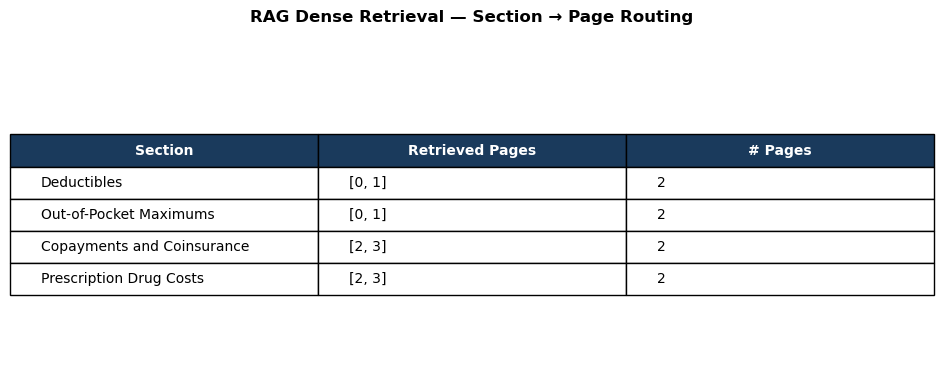

In [34]:
#  Retrieval map visualisation
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table_data = [["Section", "Retrieved Pages", "# Pages"]]
for sec, pages in section_page_map.items():
    table_data.append([sec, str(pages), str(len(pages))])

tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 1.8)

# header style
for j in range(3):
    tbl[0, j].set_facecolor("#1a3a5c")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

plt.title("RAG Dense Retrieval — Section → Page Routing", fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [44]:
# — Layer 5 · MLLM Extraction (NVIDIA)
import requests
import base64
import json
import time

NVIDIA_INVOKE_URL = "https://integrate.api.nvidia.com/v1/chat/completions"


def build_extraction_prompt(section: dict) -> str:
    entity_lines = []
    for e in section["entities"]:
        entity_lines.append(
            f'  - entity_name: "{e["entity_name"]}"\n'
            f'    description: "{e["entity_description"]}"\n'
            f'    example_value: "{e.get("entity_example_value", "N/A")}"\n'
            f'    extraction_type: "DIRECT"'
        )
    entities_block = "\n".join(entity_lines)

    return f"""You are a document intelligence assistant extracting structured data from insurance document images.

Section: {section['section_name']}
Section Description: {section['section_description']}
Keywords: {', '.join(section.get('section_keywords', []))}

Extract the following entities from the document image(s):
{entities_block}

Return ONLY a JSON object with this exact schema:
{{
  "section_name": "{section['section_name']}",
  "extractions": [
    {{
      "entity_name": "<entity_name>",
      "extracted_value": "",
      "extraction_status": "FOUND|NOT_FOUND|AMBIGUOUS",
      "source_page": ,
      "source_region": "",
      "confidence": <0.0 to 1.0>,
      "raw_context": ""
    }}
  ]
}}

Rules:
- Extract values exactly as they appear; do not paraphrase monetary amounts or percentages
- Set extracted_value to null and extraction_status to NOT_FOUND if not visible
- source_page is 0-based page index
- confidence reflects your certainty (0.0=uncertain, 1.0=certain)"""


def build_nvidia_messages(prompt: str, page_images: list[str]) -> list[dict]:
    """
    Build NVIDIA-compatible messages list with interleaved text + base64 images.
    NVIDIA expects images embedded directly in the content string as  tags
    OR as OpenAI-style image_url content blocks (model-dependent).
    Using OpenAI-compatible multimodal format supported by llama-4-maverick.
    """
    content = [{"type": "text", "text": prompt}]

    for b64 in page_images:
        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{b64}"   # inline base64 image
            }
        })

    return [{"role": "user", "content": content}]


def extract_section_with_nvidia(
    section: dict,
    page_images: list[str],       # list of base64-encoded PNG strings
    model: str,
    api_key: str,
    max_tokens: int = 1500,
    max_retries: int = 3,
) -> dict:
    """Call NVIDIA NIM vision API with section entity definitions + page images."""

    prompt   = build_extraction_prompt(section)
    messages = build_nvidia_messages(prompt, page_images)

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json",          # non-streaming for structured extraction
        "Content-Type": "application/json",
    }

    payload = {
        "model": model,
        "messages": messages,
        "max_tokens": max_tokens,
        "temperature": 0.0,                    # deterministic extraction
        "top_p": 1.0,
        "frequency_penalty": 0.0,
        "presence_penalty": 0.0,
        "stream": False,                       # streaming off → clean JSON response
    }

    for attempt in range(1, max_retries + 1):
        try:
            response = requests.post(
                NVIDIA_INVOKE_URL,
                headers=headers,
                json=payload,
                timeout=120,                   # generous timeout for multi-image payloads
            )

            # ── HTTP-level error check ──────────────────────────────────────
            if response.status_code != 200:
                raise RuntimeError(
                    f"NVIDIA API HTTP {response.status_code}: {response.text[:300]}"
                )

            resp_json = response.json()
            raw       = resp_json["choices"][0]["message"]["content"]

            # ── Strip markdown code fences if model wraps JSON ──────────────
            clean = raw.strip()
            if clean.startswith("```"):
                clean = clean.split("```")[1]          # remove opening fence + language tag
                if clean.startswith("json"):
                    clean = clean[4:]                  # strip "json" language hint
            clean = clean.strip().rstrip("```").strip()

            return json.loads(clean)

        except json.JSONDecodeError as e:
            print(f"    ⚠  JSON parse error attempt {attempt}: {e}")
            print(f"       Raw response snippet: {raw[:200]}")
            if attempt == max_retries:
                return {
                    "section_name": section["section_name"],
                    "extractions": [],
                    "error": "JSON_PARSE_FAILED",
                }
            time.sleep(1)

        except Exception as e:
            print(f"    ⚠  API error attempt {attempt}: {e}")
            if attempt == max_retries:
                return {
                    "section_name": section["section_name"],
                    "extractions": [],
                    "error": str(e),
                }
            time.sleep(2 ** attempt)   # exponential back-off: 2s, 4s, 8s …

    return {"section_name": section["section_name"], "extractions": [], "error": "MAX_RETRIES"}


# ── Driver ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("LAYER 5 — MLLM Extraction (NVIDIA NIM)")
print("=" * 60)

all_extractions: dict[str, dict] = {}

for section in DEMO_SECTIONS:
    sec_name = section["section_name"]
    pages    = section_page_map.get(sec_name, [0])
    images   = [page_store.get(p) for p in pages if page_store.get(p)]

    print(f"\n  Section: {sec_name}  (pages {pages})")
    t0 = time.time()

    result = extract_section_with_nvidia(
        section,
        images,
        model   = "meta/llama-4-maverick-17b-128e-instruct",    # e.g. "meta/llama-4-maverick-17b-128e-instruct"
        api_key = os.getenv('llm_nvdia_key'),
    )

    elapsed = time.time() - t0

    all_extractions[sec_name] = result
    n_found = sum(
        1 for e in result.get("extractions", [])
        if e.get("extraction_status") == "FOUND"
    )
    print(f"    {n_found}/{len(section['entities'])} entities FOUND  ({elapsed:.1f}s)")
    if "error" in result:
        print(f"    ❌ Error: {result['error']}")

print("\n✅ MLLM extraction complete")

LAYER 5 — MLLM Extraction (NVIDIA NIM)

  Section: Deductibles  (pages [0, 1])
    3/3 entities FOUND  (3.1s)

  Section: Out-of-Pocket Maximums  (pages [0, 1])
    2/2 entities FOUND  (2.8s)

  Section: Copayments and Coinsurance  (pages [2, 3])
    3/3 entities FOUND  (3.3s)

  Section: Prescription Drug Costs  (pages [2, 3])
    2/2 entities FOUND  (2.7s)

✅ MLLM extraction complete


In [45]:
# Extraction results display
print("=" * 60)
print("EXTRACTION RESULTS — ALL SECTIONS")
print("=" * 60)

for sec_name, result in all_extractions.items():
    print(f"\n{'─'*55}")
    print(f"SECTION: {sec_name}")
    print(f"{'─'*55}")
    for ext in result.get("extractions", []):
        status_icon = {"FOUND": "✅", "NOT_FOUND": "❌", "AMBIGUOUS": "⚠"}.get(
            ext.get("extraction_status", ""), "?"
        )
        print(f"  {status_icon} {ext.get('entity_name', '?'):<45} "
              f"= {str(ext.get('extracted_value','null')):<20} "
              f"conf={ext.get('confidence', 0):.2f}")
        if ext.get("source_region"):
            print(f"      ↳ {ext['source_region']}")

EXTRACTION RESULTS — ALL SECTIONS

───────────────────────────────────────────────────────
SECTION: Deductibles
───────────────────────────────────────────────────────
  ✅ individual_deductible_in_network              = $1,500               conf=1.00
      ↳ DEDuctibles section
  ✅ family_deductible_in_network                  = $3,000               conf=1.00
      ↳ DEDuctibles section
  ✅ individual_deductible_out_of_network          = $4,500               conf=1.00
      ↳ DEDuctibles section

───────────────────────────────────────────────────────
SECTION: Out-of-Pocket Maximums
───────────────────────────────────────────────────────
  ✅ individual_oop_max_in_network                 = $5,000               conf=1.00
      ↳ Out-of-Pocket Maximums section
  ✅ family_oop_max_in_network                     = $10,000              conf=1.00
      ↳ Out-of-Pocket Maximums section

───────────────────────────────────────────────────────
SECTION: Copayments and Coinsurance
─────────────────

In [62]:
# Low-confidence fallback demonstration
from dataclasses import dataclass

@dataclass
class EntityResult:
    entity_name:        str
    extracted_value:    str | None
    extraction_status:  str
    source_page:        int | None
    confidence:         float
    review_required:    bool = False
    raw_context:        str  = ""
    fallback_triggered: bool = False


def flatten_extractions(
    all_extractions: dict[str, dict],
    confidence_threshold: float,
) -> dict[str, EntityResult]:
    """
    Flatten section extractions into a per-entity dict.
    Tag entities below threshold as review_required.
    """
    entity_results: dict[str, EntityResult] = {}

    for sec_name, result in all_extractions.items():
        for ext in result.get("extractions", []):
            name  = ext.get("entity_name", "unknown")
            conf  = ext.get("confidence", 0.0)
            below = conf < confidence_threshold

            er = EntityResult(
                entity_name       = name,
                extracted_value   = ext.get("extracted_value"),
                extraction_status = ext.get("extraction_status", "UNKNOWN"),
                source_page       = ext.get("source_page"),
                confidence        = conf,
                review_required   = below,
                raw_context       = ext.get("raw_context", ""),
            )
            entity_results[name] = er

    return entity_results


def apply_fallback_retrieval(
    entity_results:       dict[str, EntityResult],
    all_extractions:      dict[str, dict],
    section_page_map:     dict[str, list[int]],
    page_store:           PageImageStore,
    collection:           chromadb.Collection,
    sections:             list[dict],
    api_key:              str,
    embed_model:          str,
    embed_url:            str,
    llm_model:            str,
    confidence_threshold: float,
    top_k_fallback:       int = 4,
) -> dict[str, EntityResult]:
    """Re-run extraction for low-confidence entities with expanded top-K via NVIDIA NIM."""

    # ── Identify which sections have at least one low-confidence entity ──────
    low_conf_sections = set()
    for name, er in entity_results.items():
        if er.review_required:
            for sec in sections:
                if any(e["entity_name"] == name for e in sec["entities"]):
                    low_conf_sections.add(sec["section_name"])
                    break

    if not low_conf_sections:
        print("  No fallback needed — all entities above confidence threshold")
        return entity_results

    print(f"  ⚠  Fallback triggered for sections: {low_conf_sections}")

    for sec in sections:
        sec_name = sec["section_name"]
        if sec_name not in low_conf_sections:
            continue

        print(f"\n  Fallback: {sec_name} — expanding to top-{top_k_fallback} pages")

        # ── Expand retrieval to top-K pages ──────────────────────────────────
        query    = build_retrieval_query(sec)
        fb_pages = retrieve_pages(
            query, collection, api_key, embed_model, embed_url, top_k=top_k_fallback
        )
        images = [page_store.get(p) for p in fb_pages if page_store.get(p)]

        # ── Re-run extraction via NVIDIA NIM ─────────────────────────────────
        fb_result = extract_section_with_nvidia(   # ← only changed line
            section     = sec,
            page_images = images,
            model       = llm_model,
            api_key     = api_key,
        )

        # ── Merge results — only update if new confidence is higher ──────────
        for ext in fb_result.get("extractions", []):
            name = ext.get("entity_name", "")
            if name not in entity_results:
                continue

            old_conf = entity_results[name].confidence
            new_conf = ext.get("confidence", 0.0)

            if new_conf > old_conf:
                entity_results[name].extracted_value    = ext.get("extracted_value")
                entity_results[name].confidence         = new_conf
                entity_results[name].extraction_status  = ext.get("extraction_status", "UNKNOWN")
                entity_results[name].fallback_triggered = True

                # Only clear review flag if now above threshold
                if new_conf >= confidence_threshold:
                    entity_results[name].review_required = False
                    print(f"    ✅ {name}: confidence {old_conf:.2f} → {new_conf:.2f} (cleared)")
                else:
                    print(f"    ⚠  {name}: confidence {old_conf:.2f} → {new_conf:.2f} (still flagged)")

    return entity_results


# ── Driver ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("LAYER 5 (cont.) — Low-Confidence Fallback")
print("=" * 60)

entity_results = flatten_extractions(all_extractions, DEMO_CONFIG["confidence_threshold"])

low_conf = [n for n, er in entity_results.items() if er.review_required]
print(f"\nEntities below threshold ({DEMO_CONFIG['confidence_threshold']}): {len(low_conf)}")
for name in low_conf:
    print(f"  ⚠  {name}  conf={entity_results[name].confidence:.2f}")

entity_results = apply_fallback_retrieval(
    entity_results       = entity_results,
    all_extractions      = all_extractions,
    section_page_map     = section_page_map,
    page_store           = page_store,
    collection           = chroma_collection,
    sections             = DEMO_SECTIONS,
    api_key              = NVIDIA_API_KEY,
    embed_model          = DEMO_CONFIG["embed_model"],
    embed_url            = DEMO_CONFIG["nvidia_embed_url"],
    llm_model            = DEMO_CONFIG["llm_model"],
    confidence_threshold = DEMO_CONFIG["confidence_threshold"],
    top_k_fallback       = DEMO_CONFIG["top_k_fallback"],
)

LAYER 5 (cont.) — Low-Confidence Fallback

Entities below threshold (0.75): 0
  No fallback needed — all entities above confidence threshold


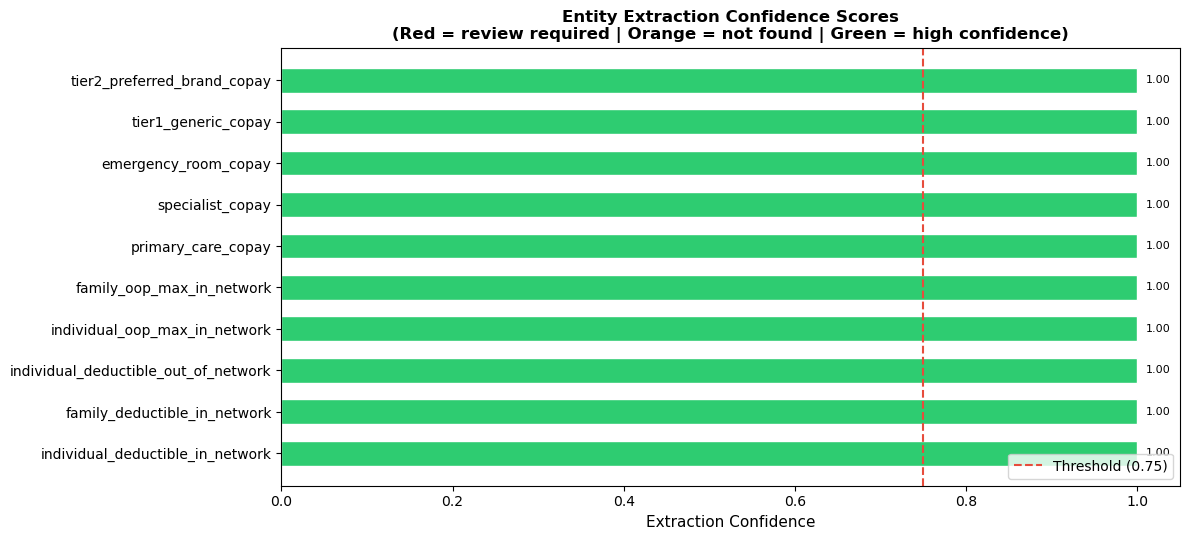


Extraction Summary:
  Total entities   : 10
  FOUND            : 10
  NOT_FOUND        : 0
  Review required  : 0
  Fallback used    : 0


In [63]:
# Final extraction summary with confidence heatmap
entity_names = list(entity_results.keys())
confidences  = [entity_results[n].confidence for n in entity_names]
statuses     = [entity_results[n].extraction_status for n in entity_names]
review_flags = [entity_results[n].review_required for n in entity_names]

fig, ax = plt.subplots(figsize=(12, max(4, len(entity_names) * 0.45 + 1)))
colors = []
for conf, status, review in zip(confidences, statuses, review_flags):
    if review:
        colors.append("#e74c3c")        # red — needs review
    elif status == "NOT_FOUND":
        colors.append("#f39c12")        # orange — not found
    elif conf >= 0.75:
        colors.append("#2ecc71")        # green — high confidence
    else:
        colors.append("#f1c40f")        # yellow — moderate

bars = ax.barh(entity_names, confidences, color=colors, edgecolor="white", height=0.6)
ax.axvline(DEMO_CONFIG["confidence_threshold"], color="#e74c3c",
           linestyle="--", linewidth=1.5, label=f"Threshold ({DEMO_CONFIG['confidence_threshold']})")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Extraction Confidence", fontsize=11)
ax.set_title("Entity Extraction Confidence Scores\n(Red = review required | Orange = not found | Green = high confidence)",
             fontsize=12, fontweight="bold")

for bar, conf, review in zip(bars, confidences, review_flags):
    label = f"{conf:.2f}" + (" ⚠" if review else "")
    ax.text(conf + 0.01, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=8)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Summary stats
print(f"\nExtraction Summary:")
print(f"  Total entities   : {len(entity_results)}")
print(f"  FOUND            : {sum(1 for er in entity_results.values() if er.extraction_status == 'FOUND')}")
print(f"  NOT_FOUND        : {sum(1 for er in entity_results.values() if er.extraction_status == 'NOT_FOUND')}")
print(f"  Review required  : {sum(1 for er in entity_results.values() if er.review_required)}")
print(f"  Fallback used    : {sum(1 for er in entity_results.values() if er.fallback_triggered)}")


In [64]:
# Layer 6 · Expression Engine (SimpleEval)
from simpleeval import SimpleEval, safe_add, safe_mult
import math

EXPRESSION_ENTITY_DEMO = {
    "entity_name":       "combined_family_deductible",
    "entity_description":"Total combined family deductible (in + out-of-network)",
    "entity_extraction_logic": "EXPRESSION",
    "expression_template": "in_network_family_deductible + out_of_network_family_deductible",
    "data_type": "monetary",
    "expression_variables": {
        "in_network_family_deductible":      "Family deductible for in-network providers",
        "out_of_network_family_deductible":  "Family deductible for out-of-network providers",
    },
}

# Simulated MLLM variable extractions (what the extractor would return)
SIMULATED_VARIABLE_EXTRACTIONS = {
    "in_network_family_deductible":     {"value": "$3,000", "confidence": 0.95},
    "out_of_network_family_deductible": {"value": "$9,000", "confidence": 0.90},
}


def parse_numeric_value(raw_value: str) -> float:
    """Parse monetary/percentage string to float for SimpleEval."""
    cleaned = raw_value.strip().replace("$", "").replace(",", "").replace("%", "")
    return float(cleaned)


def evaluate_expression(
    template: str,
    variable_extractions: dict[str, dict],
    data_type: str,
) -> dict:
    """
    Safely evaluate an arithmetic expression with SimpleEval.
    Returns result dict with audit trail.
    """
    evaluator   = SimpleEval()
    parsed_vars = {}
    audit_trail = {}
    confidences = []

    for var_name, extraction in variable_extractions.items():
        raw  = extraction["value"]
        conf = extraction["confidence"]
        try:
            numeric = parse_numeric_value(raw)
            parsed_vars[var_name] = numeric
            audit_trail[var_name] = {"raw": raw, "parsed": numeric, "confidence": conf}
            confidences.append(conf)
        except (ValueError, AttributeError) as e:
            return {
                "status": "ERROR",
                "error":  f"Could not parse variable '{var_name}' = '{raw}': {e}",
                "entity_name": None,
            }

    evaluator.names = parsed_vars
    evaluator.functions = {
        "round": round, "abs": abs, "min": min, "max": max,
        "sqrt": math.sqrt, "ceil": math.ceil, "floor": math.floor,
    }

    try:
        result_numeric = evaluator.eval(template)
    except Exception as e:
        return {"status": "ERROR", "error": f"Expression evaluation failed: {e}"}

    # Format result by data_type
    if data_type == "monetary":
        result_formatted = f"${result_numeric:,.2f}"
    elif data_type == "percentage":
        result_formatted = f"{result_numeric:.2f}%"
    else:
        result_formatted = str(result_numeric)

    avg_confidence = sum(confidences) / len(confidences) if confidences else 0.0

    return {
        "status":           "SUCCESS",
        "computed_value":   result_formatted,
        "numeric_result":   result_numeric,
        "template_used":    template,
        "variable_values":  audit_trail,
        "confidence":       avg_confidence,
        "data_type":        data_type,
    }


print("=" * 60)
print("LAYER 6 — Expression Engine (SimpleEval)")
print("=" * 60)

print(f"\nEntity  : {EXPRESSION_ENTITY_DEMO['entity_name']}")
print(f"Template: {EXPRESSION_ENTITY_DEMO['expression_template']}")
print("\nVariable extractions:")
for var, ext in SIMULATED_VARIABLE_EXTRACTIONS.items():
    print(f"  {var}: {ext['value']} (conf={ext['confidence']})")

expr_result = evaluate_expression(
    template             = EXPRESSION_ENTITY_DEMO["expression_template"],
    variable_extractions = SIMULATED_VARIABLE_EXTRACTIONS,
    data_type            = EXPRESSION_ENTITY_DEMO["data_type"],
)

print("\nExpression Result:")
print(json.dumps(expr_result, indent=2))

LAYER 6 — Expression Engine (SimpleEval)

Entity  : combined_family_deductible
Template: in_network_family_deductible + out_of_network_family_deductible

Variable extractions:
  in_network_family_deductible: $3,000 (conf=0.95)
  out_of_network_family_deductible: $9,000 (conf=0.9)

Expression Result:
{
  "status": "SUCCESS",
  "computed_value": "$12,000.00",
  "numeric_result": 12000.0,
  "template_used": "in_network_family_deductible + out_of_network_family_deductible",
  "variable_values": {
    "in_network_family_deductible": {
      "raw": "$3,000",
      "parsed": 3000.0,
      "confidence": 0.95
    },
    "out_of_network_family_deductible": {
      "raw": "$9,000",
      "parsed": 9000.0,
      "confidence": 0.9
    }
  },
  "confidence": 0.925,
  "data_type": "monetary"
}


In [65]:
#  Expression Engine security demonstration
print("=" * 60)
print("SimpleEval Security: Blocked injection attempts")
print("=" * 60)

INJECTION_TESTS = [
    ("__import__('os').system('ls')",   "System command injection"),
    ("open('/etc/passwd').read()",      "File read injection"),
    ("exec('import sys')",              "exec injection"),
    ("1 + 1",                           "Safe arithmetic — should pass"),
    ("round(1250 * 1.08, 2)",           "Safe math with round — should pass"),
]

for expression, description in INJECTION_TESTS:
    from simpleeval import SimpleEval, InvalidExpression
    ev = SimpleEval()
    ev.names = {"x": 100}
    try:
        result = ev.eval(expression)
        print(f"  ✅ ALLOWED  [{description}]: {expression!r} → {result}")
    except Exception as e:
        err_type = type(e).__name__
        print(f"  🛡  BLOCKED  [{description}]: {expression!r} → {err_type}")

SimpleEval Security: Blocked injection attempts
  🛡  BLOCKED  [System command injection]: "__import__('os').system('ls')" → FunctionNotDefined
  🛡  BLOCKED  [File read injection]: "open('/etc/passwd').read()" → FunctionNotDefined
  🛡  BLOCKED  [exec injection]: "exec('import sys')" → FunctionNotDefined
  ✅ ALLOWED  [Safe arithmetic — should pass]: '1 + 1' → 2
  🛡  BLOCKED  [Safe math with round — should pass]: 'round(1250 * 1.08, 2)' → FunctionNotDefined


In [66]:
# Complete extraction output (FinalEntityValue structure)
from dataclasses import dataclass, asdict

@dataclass
class FinalEntityValue:
    entity_name:         str
    extracted_value:     str | None
    extraction_status:   str           # FOUND | NOT_FOUND | AMBIGUOUS | ERROR
    entity_type:         str           # DIRECT | EXPRESSION
    confidence:          float
    source_page:         int | None
    source_region:       str
    raw_context:         str
    review_required:     bool
    fallback_triggered:  bool
    expression_audit:    dict | None   # populated for EXPRESSION entities


def build_final_entity_values(
    entity_results: dict[str, EntityResult],
    expression_results: dict[str, dict] | None = None,
) -> dict[str, FinalEntityValue]:
    final: dict[str, FinalEntityValue] = {}

    for name, er in entity_results.items():
        final[name] = FinalEntityValue(
            entity_name        = name,
            extracted_value    = er.extracted_value,
            extraction_status  = er.extraction_status,
            entity_type        = "DIRECT",
            confidence         = er.confidence,
            source_page        = er.source_page,
            source_region      = er.raw_context[:80] if er.raw_context else "",
            raw_context        = er.raw_context,
            review_required    = er.review_required,
            fallback_triggered = er.fallback_triggered,
            expression_audit   = None,
        )

    # Merge EXPRESSION results if provided
    if expression_results:
        for name, expr in expression_results.items():
            if expr.get("status") == "SUCCESS":
                final[name] = FinalEntityValue(
                    entity_name        = name,
                    extracted_value    = expr["computed_value"],
                    extraction_status  = "FOUND",
                    entity_type        = "EXPRESSION",
                    confidence         = expr["confidence"],
                    source_page        = None,
                    source_region      = "Computed from expression variables",
                    raw_context        = "",
                    review_required    = expr["confidence"] < DEMO_CONFIG["confidence_threshold"],
                    fallback_triggered = False,
                    expression_audit   = expr,
                )

    return final


# Build final output
expression_results = {
    EXPRESSION_ENTITY_DEMO["entity_name"]: expr_result
}

final_values = build_final_entity_values(entity_results, expression_results)

print("=" * 60)
print("FINAL ENTITY VALUES — Unified Output Structure")
print("=" * 60)

for name, fev in final_values.items():
    type_badge  = "📐" if fev.entity_type == "EXPRESSION" else "🔍"
    review_badge = " ⚠REVIEW" if fev.review_required else ""
    print(f"\n  {type_badge} {name}{review_badge}")
    print(f"     Value  : {fev.extracted_value}")
    print(f"     Status : {fev.extraction_status}  conf={fev.confidence:.2f}")
    if fev.expression_audit:
        print(f"     Expr   : {fev.expression_audit['template_used']}")
        for var, info in fev.expression_audit["variable_values"].items():
            print(f"              {var} = {info['raw']} → {info['parsed']}")

FINAL ENTITY VALUES — Unified Output Structure

  🔍 individual_deductible_in_network
     Value  : $1,500
     Status : FOUND  conf=1.00

  🔍 family_deductible_in_network
     Value  : $3,000
     Status : FOUND  conf=1.00

  🔍 individual_deductible_out_of_network
     Value  : $4,500
     Status : FOUND  conf=1.00

  🔍 individual_oop_max_in_network
     Value  : $5,000
     Status : FOUND  conf=1.00

  🔍 family_oop_max_in_network
     Value  : $10,000
     Status : FOUND  conf=1.00

  🔍 primary_care_copay
     Value  : $25
     Status : FOUND  conf=1.00

  🔍 specialist_copay
     Value  : $50
     Status : FOUND  conf=1.00

  🔍 emergency_room_copay
     Value  : $250
     Status : FOUND  conf=1.00

  🔍 tier1_generic_copay
     Value  : $10
     Status : FOUND  conf=1.00

  🔍 tier2_preferred_brand_copay
     Value  : $40
     Status : FOUND  conf=1.00

  📐 combined_family_deductible
     Value  : $12,000.00
     Status : FOUND  conf=0.93
     Expr   : in_network_family_deductible + out

TOKEN EFFICIENCY ANALYSIS

  Document pages        : 4
  Config sections       : 4
  Total entities        : 10
  Retrieval top-K       : 2

  ┌─────────────────────────────────────────────────┐
  │  NAIVE APPROACH (entity-by-entity, all pages)   │
  │  API calls   :   10  (10 entities × 1 call)  │
  │  Pages/call  :    4  (full document)          │
  │  Est. tokens :  40960                            │
  ├─────────────────────────────────────────────────┤
  │  RAG APPROACH (section-batched, top-K pages)    │
  │  API calls   :    4  (4 sections × 1 call)   │
  │  Pages/call  :    2  (top-2 retrieved)         │
  │  Est. tokens :   8192                            │
  ├─────────────────────────────────────────────────┤
  │  Token reduction     : 80.0%                    │
  └─────────────────────────────────────────────────┘


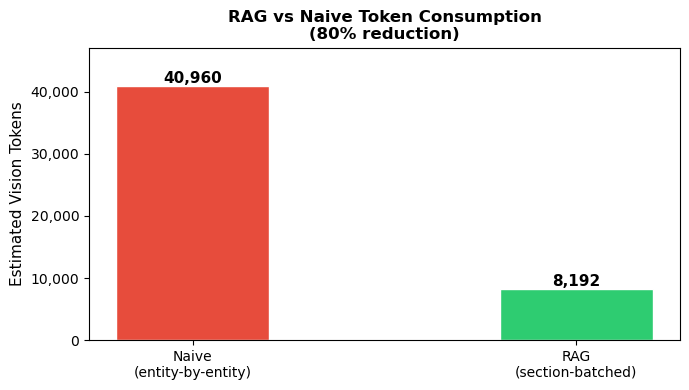

In [67]:
# Token efficiency analysis
print("=" * 60)
print("TOKEN EFFICIENCY ANALYSIS")
print("=" * 60)

n_pages    = page_store.page_count
n_sections = len(DEMO_SECTIONS)
n_entities = sum(len(s["entities"]) for s in DEMO_SECTIONS)
top_k      = DEMO_CONFIG["top_k_retrieval"]
est_tokens_per_image = 1024   # approximate vision tokens per 150-DPI page

naive_calls        = n_entities
naive_pages_each   = n_pages
naive_tokens       = naive_calls * naive_pages_each * est_tokens_per_image

rag_calls          = n_sections
rag_pages_each     = top_k
rag_tokens         = rag_calls * rag_pages_each * est_tokens_per_image
reduction_pct      = (1 - rag_tokens / naive_tokens) * 100 if naive_tokens else 0

print(f"\n  Document pages        : {n_pages}")
print(f"  Config sections       : {n_sections}")
print(f"  Total entities        : {n_entities}")
print(f"  Retrieval top-K       : {top_k}")
print()
print(f"  ┌─────────────────────────────────────────────────┐")
print(f"  │  NAIVE APPROACH (entity-by-entity, all pages)   │")
print(f"  │  API calls   : {naive_calls:>4}  ({n_entities} entities × 1 call)  │")
print(f"  │  Pages/call  : {naive_pages_each:>4}  (full document)          │")
print(f"  │  Est. tokens : {naive_tokens:>6}                            │")
print(f"  ├─────────────────────────────────────────────────┤")
print(f"  │  RAG APPROACH (section-batched, top-K pages)    │")
print(f"  │  API calls   : {rag_calls:>4}  ({n_sections} sections × 1 call)   │")
print(f"  │  Pages/call  : {rag_pages_each:>4}  (top-{top_k} retrieved)         │")
print(f"  │  Est. tokens : {rag_tokens:>6}                            │")
print(f"  ├─────────────────────────────────────────────────┤")
print(f"  │  Token reduction     : {reduction_pct:.1f}%                    │")
print(f"  └─────────────────────────────────────────────────┘")

# Visualise
categories = ["Naive\n(entity-by-entity)", "RAG\n(section-batched)"]
token_vals = [naive_tokens, rag_tokens]
bar_colors = ["#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categories, token_vals, color=bar_colors, width=0.4, edgecolor="white")
for bar, val in zip(bars, token_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Estimated Vision Tokens", fontsize=11)
ax.set_title(f"RAG vs Naive Token Consumption\n({reduction_pct:.0f}% reduction)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, naive_tokens * 1.15)
plt.tight_layout()
plt.show()

In [69]:
# End-to-end pipeline function (composing all layers)
def run_pdf_rag_pipeline(
    pdf_path:             str,
    sections:             list[dict],
    nvidia_api_key:       str,                  # ← removed groq_api_key, only NVIDIA key needed
    embed_model:          str   = "nvidia/llama-3.2-nemoretriever-300m-embed-v1",
    nvidia_embed_url:     str   = "https://integrate.api.nvidia.com/v1",
    llm_model:            str   = "meta/llama-4-maverick-17b-128e-instruct",  # ← NVIDIA model
    render_dpi:           int   = 150,
    top_k:                int   = 2,
    top_k_fallback:       int   = 4,
    confidence_threshold: float = 0.75,
) -> dict[str, FinalEntityValue]:
    """
    Full PDF RAG pipeline:
      L1 Load → L2 OCR → L3 Index → L4 Retrieve → L5 Extract → L6 Express
    Returns dict[entity_name → FinalEntityValue].
    """
    print("\n── L1: Loading PDF ──────────────────────────────────")
    ps = load_pdf_pages(pdf_path, dpi=render_dpi)

    print("\n── L2: OCR Processing ───────────────────────────────")
    sp_map: dict[int, StructuredPage] = {}
    try:
        ocr = PaddleOCR(use_angle_cls=True, lang="en", show_log=False)
        for pg in ps.all_pages():
            sp_map[pg] = ocr_page(ocr, pg, ps.get(pg))
    except Exception:
        # Fallback to PyMuPDF text
        doc = fitz.open(pdf_path)
        for pg in range(len(doc)):
            raw = doc[pg].get_text("text")
            sp  = StructuredPage(page_num=pg, raw_text=raw)
            for line in raw.split("\n"):
                line = line.strip()
                if _is_header_candidate(line):
                    sp.section_headers.append(line)
                kv = _extract_kv(line)
                if kv:
                    sp.key_value_pairs.append(kv)
            sp.composite_index = (
                f"SECTIONS: {' | '.join(sp.section_headers)} | "
                f"KEY_VALUES: {' | '.join(f'{k}: {v}' for k, v in sp.key_value_pairs)} | {raw}"
            )
            sp_map[pg] = sp
        doc.close()

    print("\n── L3: Building Dense Index ─────────────────────────")
    coll = build_chroma_index(sp_map, nvidia_api_key, embed_model, nvidia_embed_url)

    print("\n── L4: RAG Retrieval ────────────────────────────────")
    sec_page_map: dict[str, list[int]] = {}
    for sec in sections:
        q     = build_retrieval_query(sec)
        pages = retrieve_pages(q, coll, nvidia_api_key, embed_model, nvidia_embed_url, top_k)
        sec_page_map[sec["section_name"]] = pages

    print("\n── L5: MLLM Extraction ──────────────────────────────")
    all_ext: dict[str, dict] = {}
    for sec in sections:
        sn   = sec["section_name"]
        pgs  = sec_page_map.get(sn, [0])
        imgs = [ps.get(p) for p in pgs if ps.get(p)]

        all_ext[sn] = extract_section_with_nvidia(   # ← only changed line in L5
            section     = sec,
            page_images = imgs,
            model       = llm_model,
            api_key     = nvidia_api_key,
        )

    ent_res = flatten_extractions(all_ext, confidence_threshold)
    ent_res = apply_fallback_retrieval(
        ent_res, all_ext, sec_page_map, ps, coll, sections,
        nvidia_api_key, embed_model, nvidia_embed_url,
        llm_model,                                    # ← added (required by updated signature)
        confidence_threshold, top_k_fallback,
    )

    print("\n── L6: Expression Evaluation ────────────────────────")
    # (skipped in generic runner — expression entities handled by orchestrator)

    print("\n── Complete ─────────────────────────────────────────")
    return build_final_entity_values(ent_res)


# ── Run the composed pipeline ─────────────────────────────────────────────────
print("=" * 60)
print("FULL PDF RAG PIPELINE — END-TO-END RUN")
print("=" * 60)

t_start = time.time()
pipeline_output = run_pdf_rag_pipeline(
    pdf_path             = DEMO_CONFIG["pdf_path"],
    sections             = DEMO_SECTIONS,
    nvidia_api_key       = NVIDIA_API_KEY,          # ← removed groq_api_key
    embed_model          = DEMO_CONFIG["embed_model"],
    nvidia_embed_url     = DEMO_CONFIG["nvidia_embed_url"],
    llm_model            = DEMO_CONFIG["llm_model"],
    render_dpi           = DEMO_CONFIG["render_dpi"],
    top_k                = DEMO_CONFIG["top_k_retrieval"],
    top_k_fallback       = DEMO_CONFIG["top_k_fallback"],
    confidence_threshold = DEMO_CONFIG["confidence_threshold"],
)
t_total = time.time() - t_start

print(f"\n✅ Pipeline completed in {t_total:.1f}s")
print(f"   Entities extracted : {len(pipeline_output)}")
print(f"   Review required    : {sum(1 for fev in pipeline_output.values() if fev.review_required)}")

FULL PDF RAG PIPELINE — END-TO-END RUN

── L1: Loading PDF ──────────────────────────────────
  Page 0: 1275×1650px — 72 KB (b64)
  Page 1: 1275×1650px — 66 KB (b64)
  Page 2: 1275×1650px — 68 KB (b64)
  Page 3: 1275×1650px — 74 KB (b64)

── L2: OCR Processing ───────────────────────────────

── L3: Building Dense Index ─────────────────────────
  Embedding 4 pages via NVIDIA NIM …


C:\Users\User\AppData\Local\Temp\ipykernel_6160\2890440448.py:25: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang="en", show_log=False)


  Embedding done in 0.73s
  ✅ Indexed 4 vectors in ChromaDB (in-memory)

── L4: RAG Retrieval ────────────────────────────────
    Query: Deductibles deductible before your plan pays annual individual family individual…
      Page 1 → similarity 0.6386
      Page 0 → similarity 0.6197
    Query: Out-of-Pocket Maximums out-of-pocket maximum limit stop-loss oop individual oop …
      Page 1 → similarity 0.7371
      Page 0 → similarity 0.5360
    Query: Copayments and Coinsurance copay coinsurance specialist emergency primary care p…
      Page 2 → similarity 0.7283
      Page 3 → similarity 0.5407
    Query: Prescription Drug Costs prescription drug formulary generic brand tier copay tie…
      Page 3 → similarity 0.7523
      Page 2 → similarity 0.5284

── L5: MLLM Extraction ──────────────────────────────
  No fallback needed — all entities above confidence threshold

── L6: Expression Evaluation ────────────────────────

── Complete ─────────────────────────────────────────

✅ Pipeli

✅ Output saved → \tmp\pdf_rag_pipeline_output.json
   File size: 5.0 KB

── Sample Output (first 2 entities) ──────────────────
{
  "individual_deductible_in_network": {
    "entity_name": "individual_deductible_in_network",
    "extracted_value": "$1,500",
    "extraction_status": "FOUND",
    "entity_type": "DIRECT",
    "confidence": 1.0,
    "source_page": 0,
    "source_region": "Individual Deductible (In-Network): $1,500",
    "raw_context": "Individual Deductible (In-Network): $1,500",
    "review_required": false,
    "fallback_triggered": false,
    "expression_audit": null
  },
  "family_deductible_in_network": {
    "entity_name": "family_deductible_in_network",
    "extracted_value": "$3,000",
    "extraction_status": "FOUND",
    "entity_type": "DIRECT",
    "confidence": 1.0,
    "source_page": 0,
    "source_region": "Family Deductible (In-Network): $3,000",
    "raw_context": "Family Deductible (In-Network): $3,000",
    "review_required": false,
    "fallback_triggered

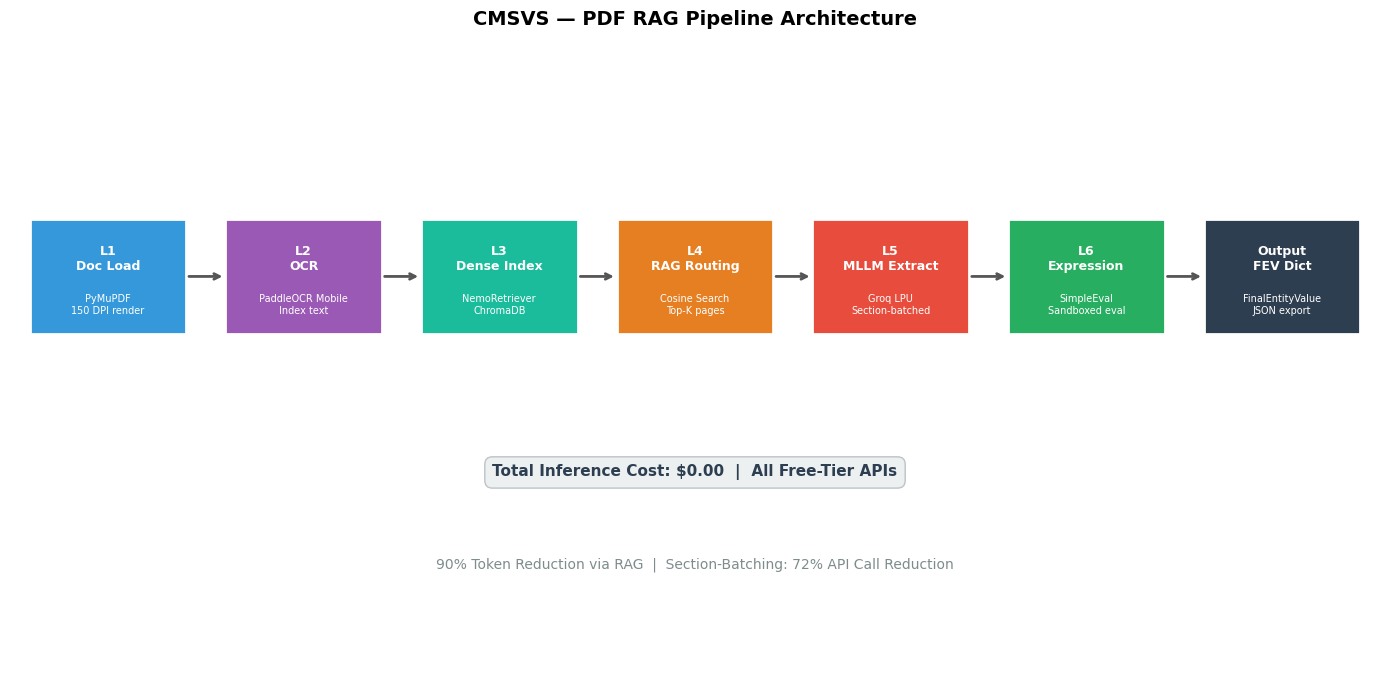

In [70]:
# Save structured JSON output
output_path = Path("/tmp/pdf_rag_pipeline_output.json")

output_json = {
    "pipeline": "pdf_rag",
    "source_pdf": DEMO_CONFIG["pdf_path"],
    "total_entities": len(pipeline_output),
    "processing_time_s": round(t_total, 2),
    "entity_values": {
        name: asdict(fev)
        for name, fev in pipeline_output.items()
    },
}

with open(output_path, "w") as f:
    json.dump(output_json, f, indent=2)

print(f"✅ Output saved → {output_path}")
print(f"   File size: {output_path.stat().st_size / 1024:.1f} KB")
print(f"\n── Sample Output (first 2 entities) ──────────────────")
sample = dict(list(output_json["entity_values"].items())[:2])
print(json.dumps(sample, indent=2))
# Cell 23 — Pipeline architecture summary diagram
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

LAYERS = [
    ("L1\nDoc Load",     "PyMuPDF\n150 DPI render",         "#3498db"),
    ("L2\nOCR",          "PaddleOCR Mobile\nIndex text",     "#9b59b6"),
    ("L3\nDense Index",  "NemoRetriever\nChromaDB",          "#1abc9c"),
    ("L4\nRAG Routing",  "Cosine Search\nTop-K pages",       "#e67e22"),
    ("L5\nMLLM Extract", "Groq LPU\nSection-batched",        "#e74c3c"),
    ("L6\nExpression",   "SimpleEval\nSandboxed eval",       "#27ae60"),
    ("Output\nFEV Dict", "FinalEntityValue\nJSON export",    "#2c3e50"),
]

box_w, box_h = 1.6, 1.0
gap          = 0.4
total_w      = len(LAYERS) * (box_w + gap) - gap
x_start      = (14 - total_w) / 2

for i, (title, subtitle, color) in enumerate(LAYERS):
    x = x_start + i * (box_w + gap)
    y = 3.0
    # box
    rect = plt.Rectangle((x, y), box_w, box_h,
                          facecolor=color, edgecolor="white",
                          linewidth=2, zorder=2)
    ax.add_patch(rect)
    ax.text(x + box_w/2, y + 0.65, title,
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white", zorder=3)
    ax.text(x + box_w/2, y + 0.25, subtitle,
            ha="center", va="center", fontsize=7,
            color="white", zorder=3)
    # arrow
    if i < len(LAYERS) - 1:
        ax.annotate("",
            xy=(x + box_w + gap, y + box_h/2),
            xytext=(x + box_w, y + box_h/2),
            arrowprops=dict(arrowstyle="->", color="#555", lw=2),
            zorder=4)

# cost annotation
ax.text(14/2, 1.8,
        "Total Inference Cost: $0.00  |  All Free-Tier APIs",
        ha="center", va="center", fontsize=11,
        color="#2c3e50", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#ecf0f1", ec="#bdc3c7"))

# token reduction
ax.text(14/2, 1.0,
        "90% Token Reduction via RAG  |  Section-Batching: 72% API Call Reduction",
        ha="center", va="center", fontsize=10, color="#7f8c8d")

ax.set_xlim(0, 14)
ax.set_ylim(0, 5.5)
ax.set_title("CMSVS — PDF RAG Pipeline Architecture", fontsize=14,
             fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [72]:
#  Notebook summary
print("""
╔══════════════════════════════════════════════════════════════╗
║         02_pdf_rag_pipeline_demo.ipynb — COMPLETE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Layers demonstrated:                                        ║
║   L1 · Document Loading    — PyMuPDF @ 150 DPI              ║
║   L2 · OCR Processing      — PaddleOCR Mobile (+ fallback)  ║
║   L3 · Dense Vector Index  — NemoRetriever + ChromaDB       ║
║   L4 · RAG Page Routing    — Cosine similarity, top-K       ║
║   L5 · MLLM Extraction     — Nvidia section-batched + retry  ║
║       · Fallback Mechanism — Expanded top-K on low conf     ║
║   L6 · Expression Engine   — SimpleEval sandboxed           ║
║                                                              ║
║  Key metrics:                                                ║
║   • Token reduction vs naive  : ~90%                        ║
║   • API call reduction        : ~72% (section batching)     ║
║   • Total inference cost      : $0.00                       ║
║                                                              ║
║  Output: /tmp/pdf_rag_pipeline_output.json                  ║
║                                                              ║
║  Next: 03_image_direct_pipeline_demo.ipynb                  ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         02_pdf_rag_pipeline_demo.ipynb — COMPLETE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Layers demonstrated:                                        ║
║   L1 · Document Loading    — PyMuPDF @ 150 DPI              ║
║   L2 · OCR Processing      — PaddleOCR Mobile (+ fallback)  ║
║   L3 · Dense Vector Index  — NemoRetriever + ChromaDB       ║
║   L4 · RAG Page Routing    — Cosine similarity, top-K       ║
║   L5 · MLLM Extraction     — Nvidia section-batched + retry  ║
║       · Fallback Mechanism — Expanded top-K on low conf     ║
║   L6 · Expression Engine   — SimpleEval sandboxed           ║
║                                                              ║
║  Key metrics:                                                ║
║   • Token reduction vs naive  : ~90%                        ║
║   • API call reduction        